In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("Ice_cream selling data.csv")

The `df.corr() `function is used to calculate the correlation between all numerical columns in the dataset. 

It helps identify how `strongly features` are related to each other and to the `target variable`

In [3]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [4]:
X=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']

**Polynomial regression**

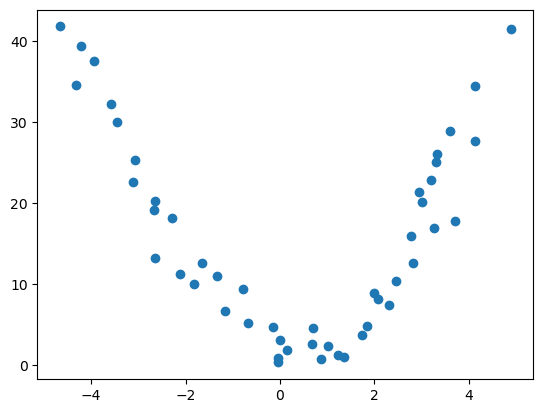

In [5]:

plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


The dataset is split into training and testing sets using `train_test_split()`.

In [7]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=0)

The `PolynomialFeatures` class is used to generate new features by combining the original features with their higher-degree terms.

This transformation enables a linear regression model to learn **non-linear patterns** in the dataset.

In [8]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)

### Transforming the Training and Testing Data

The polynomial transformation is applied to the training and testing datasets

**`fit_transform(Xtrain)`**
  - Learns the polynomial feature mapping from the training data.
  - Converts the training data into polynomial features.

  **`transform(Xtest)`**
  - Applies the same polynomial transformation learned from the training data to the testing data.
  - Does not fit the transformer again, preventing data leakage.

In [9]:
update_Xtrain=poly.fit_transform(Xtrain)
update_Xtest=poly.transform(Xtest)

In [10]:
Xtrain

,Temperature (°C)
11,-2.288264
31,1.850552
33,2.075101
27,1.024181
48,4.899032
2,-4.213985
46,4.130868
18,-0.673753
15,-1.326379
28,1.240712


### Training the Polynomial Regression Model

A Linear Regression model is trained using the polynomial-transformed training data.


The `fit()` method learns the relationship between the polynomial features and the target variable.

**Explanation:**
- **`LinearRegression()`** creates a linear regression model.
- **`model.fit(update_Xtrain, ytrain)`** trains the model using the polynomial-transformed training data and the corresponding target values.
- The model learns the relationship between the polynomial features and the target variable by minimizing the prediction error.

In [11]:
model = LinearRegression()
model.fit(update_Xtrain,ytrain)

LinearRegression()

After training the model, predictions are generated for the transformed training dataset.

**Explanation:**
- **`model.predict()`** uses the trained polynomial regression model to estimate the target values.
- **`update_Xtrain`** contains the polynomial-transformed training features.
- **`ypred_train`** stores the predicted values for the training dataset.

These predictions are later compared with the actual target values (`ytrain`) to evaluate the model's performance using metrics such as **R² Score, MAE, MSE,** and **RMSE**.

In [12]:
ypred_train=model.predict(update_Xtrain)


The trained polynomial regression model is used to predict the target values for the training dataset. The scatter plot is then used to compare the **actual** and **predicted** values.

**Explanation:**
- `model.predict(update_Xtrain)` generates predictions for the transformed training data.
- `plt.scatter(update_Xtrain[:,1], ytrain)` plots the actual target values.
- `plt.scatter(update_Xtrain[:,1], ypred_train)` plots the predicted target values.


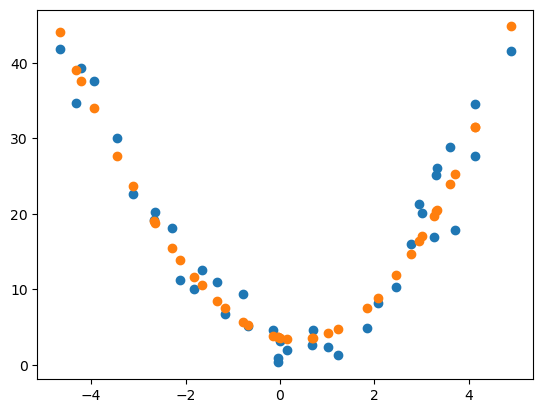

In [13]:
ypred_train=model.predict(update_Xtrain)
plt.scatter(update_Xtrain[:,1],ytrain)
plt.scatter(update_Xtrain[:,1],ypred_train) 

The **R² Score (Coefficient of Determination)** is used to evaluate how well the polynomial regression model fits the training data.

**Explanation:**
- **`ytrain`**: Actual target values of the training dataset.
- **`ypred_train`**: Predicted target values generated by the model.
- **`r2_score()`**: Measures the proportion of variance in the target variable explained by the model.

**Interpretation:**
- **R² = 1.0** → Perfect fit.
- **R² close to 1** → Excellent model performance.
- **R² close to 0** → Poor model performance.
- **R² < 0** → The model performs worse than predicting the mean value.

In [14]:
train_score=r2_score(ytrain,ypred_train)

After training the polynomial regression model, predictions are generated for the testing dataset and evaluated using multiple performance metrics.

**Explanation:**
- **`model.predict(update_Xtest)`**: Predicts the target values for the transformed testing dataset.
- **`r2_score(ytest, ypred_test)`**: Measures how well the model explains the variance in the test data.
- **`mean_absolute_error(ytest, ypred_test)`**: Calculates the average absolute difference between the actual and predicted values.
- **`root_mean_squared_error(ytest, ypred_test)`**: Computes the square root of the average squared prediction errors. Lower RMSE indicates better model performance.

These metrics help evaluate the model's ability to make accurate predictions on unseen data.

In [15]:
ypred_test=model.predict(update_Xtest)
test_score=r2_score(ytest,ypred_test)
print(f"Test Score :{test_score}")


Test Score :0.892080222419145


In [16]:
mae=mean_absolute_error(ytest,ypred_test)
rmse=root_mean_squared_error(ytest,ypred_test)
print(f"MAE : {mae}")
print(f"RMSE: {rmse}")

MAE : 3.1166037673596927
RMSE: 3.3636669822399714


`Bias` : Low

`Variance` : Low 

`Model` : good fit (Generalization : good (the model performs well on unseen data))
